In [5]:
import sys
import os
import csv
import yaml

import math
import pandas as pd
import numpy as np
from scipy import signal
from scipy.signal import butter, filtfilt
import statistics as st
import matplotlib.pyplot as plt
import json
import random

samples = 211

data_path = './data'
gravity_acceleration = 9.806
cutoff = 2

In [6]:
def plot_accelerometer(accel_data, peaks):
    """
    Plots the filtered accelerometer magnitude with detected peaks.
    Input:
        accel_data - dict returned by prepare_accelerometer_data()
        peaks      - list of peak indices returned by detect_peaks()
    """
    time = accel_data['experiment_time']
    mag  = accel_data['accel_magnitude']

    plt.figure(figsize=(16, 6))
    plt.plot(time, mag, label='Filtered Acceleration', color='blue', linewidth=1)
    plt.scatter(
        [time[j] for j in peaks],
        [mag[j]  for j in peaks],
        color='red', marker='o', label='Detected Peaks'
    )
    plt.title('Filtered Accelerometer Magnitude')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Acceleration (m/s²)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

Sample User Characteristics:
User Id: 110
User Age: 27


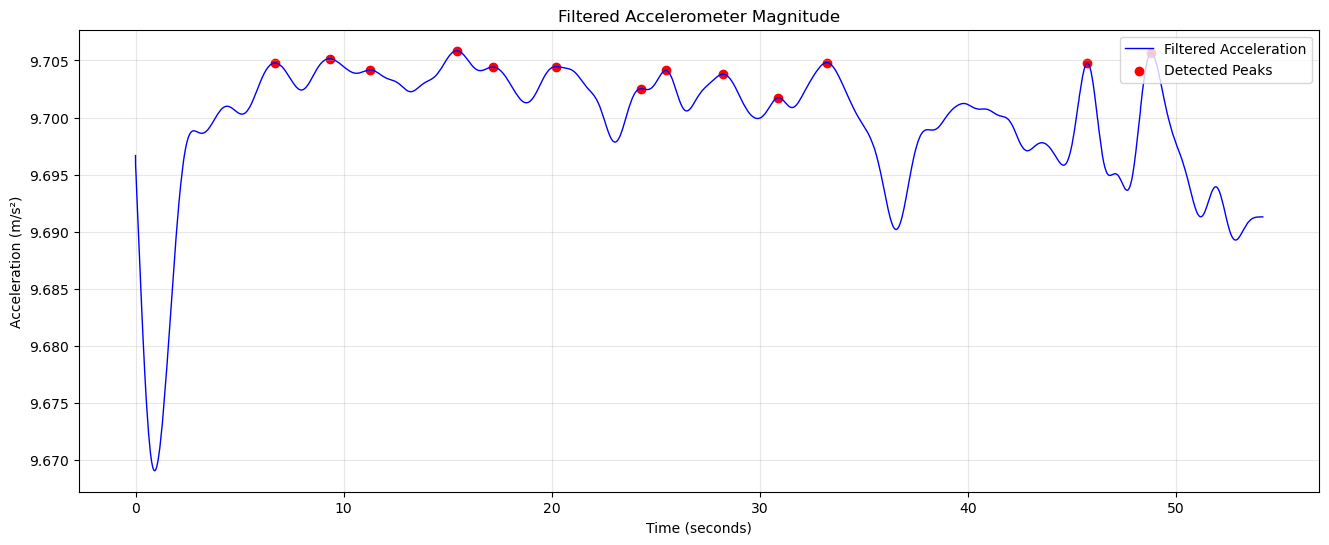

In [7]:
from helpers import prepare_accelerometer_data, detect_peaks, compute_step_metrics

### read all files for random sample and print info
a = random.randint(1,samples)
sample_path = os.path.join(data_path,str(a))
json_path = os.path.join(sample_path,'user_data.json')
#read data and visualize
with open(json_path, 'r', encoding= 'utf-8') as f:
    sample_data =  json.load(f)
    user_id = sample_data['user_id']
    user_age = sample_data['age']
    user_weight = sample_data['weight_kg']
    user_height = sample_data['height_cm']
    user_gender = sample_data['gender']
    phone_location = sample_data['phone_location']
    high_height_cm = sample_data['high_height_cm']
    print("Sample User Characteristics:")
    print("User Id:",user_id)
    print("User Age:",user_age)

    data_values={}
    accel_file = sample_path + '/' + 'accelerometer.txt'
    with open(accel_file, 'r') as f:
        accel_data = f.readlines()
        data_values['accelerometer'] = []
        for time_instant in accel_data[1:]:
            time_instant = time_instant.split()
            data_values['accelerometer'] = data_values['accelerometer'] + \
                    [[eval(time_instant[0]), [eval(component) for component in time_instant[1:]]]]
        ### Accelerometer
        accel_data = prepare_accelerometer_data(data_values)
        peaks = detect_peaks(accel_data)
        plot_accelerometer(accel_data, peaks)
        peaks = detect_peaks(accel_data)
        metrics = compute_step_metrics(accel_data, peaks)